# eff plots for thesis

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg

# using file 29: final thesis plot for chapter 5

In [6]:
output = coffea.util.load(f"outputs/bkg_29_41.coffea")
# out = output["out"]
for k in output:
    print(k) # find samples
# sss = "2Mu2E_200GeV_5p0GeV_100p0mm"
# print(*out[sss]["hists"].keys(), sep="\n") #find hist

4Mu_500GeV_0p25GeV_0p004mm
4Mu_500GeV_0p25GeV_0p04mm
4Mu_500GeV_0p25GeV_0p4mm
4Mu_500GeV_0p25GeV_2p0mm


In [3]:
channels = ["baseNoLj", "ljsource_cuts", "gen_level_cuts"]
ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
chan = [ch1, ch2, ch3]

figw, figh = 12, 10

s2mu = [
    "2Mu2E_200GeV_5p0GeV_100p0mm",
"2Mu2E_500GeV_5p0GeV_80p0mm",
"2Mu2E_800GeV_5p0GeV_50p0mm",
"2Mu2E_1000GeV_5p0GeV_40p0mm",
"2Mu2E_500GeV_0p25GeV_4p0mm",
"2Mu2E_500GeV_1p2GeV_0p019mm",
"2Mu2E_500GeV_1p2GeV_0p19mm",
"2Mu2E_500GeV_1p2GeV_1p9mm",
"2Mu2E_500GeV_1p2GeV_9p6mm",
"2Mu2E_500GeV_1p2GeV_19p0mm",
       ]

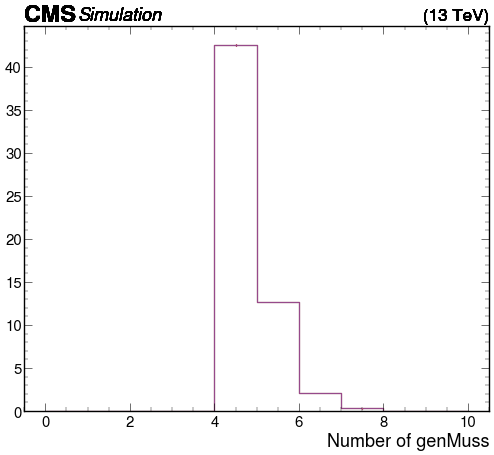

In [8]:
htoplot = ["genMu_n"]
for htp in htoplot:
    plt.subplots(1, 1, figsize=(figw, figh))
    for sss in s2mu:
        utilities.plot(output["4Mu_500GeV_0p25GeV_0p004mm"]["hists"][htp][ch1, :], label = "cha2name[ij]")

In [5]:
vamos mijo

SyntaxError: invalid syntax (3058934448.py, line 1)

# using file 9

In [ ]:
vrs = ["09", "10", "12", "13"]

for vr in vrs:
    print(f"\n=== efficiency_{vr}.coffea ===")

    output = coffea.util.load(f"outputs/efficiency_{vr}.coffea")
    out = output["out"]

    sample = next(iter(out))   # first sample in the file

    print(f"Sample: {sample}")
    print(*out[sample]["hists"].keys(), sep="\n")

In [ ]:
# vrs = ["09", "10", "12", "13"]
# for i in vrs:
#     print(i)
#     output = coffea.util.load(f"outputs/efficiency_{i}.coffea")
#     out = output["out"]
#     sample = str(output.keys()[0])    
#     print(out[sample]["hists"].keys(), "\n")
    

In [ ]:
sample = "2Mu2E_100GeV_5p0GeV_400mm"

print(out[sample]["hists"].keys())

In [ ]:
sss = "2Mu2E_100GeV_5p0GeV_400mm"
ch2 = "dsa_eff_with_OR"


In [ ]:
# plots 1 and 2 pf and dsa for lxy
output = coffea.util.load("outputs/efficiency_09.coffea")
out = output["out"]

for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 2, figsize=(2*figw, figh))
    num = out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
    den = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="", capsize=2)
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(fr"${mu}^{{\mathrm{{Leading}}}}_{{\mu}}$")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    hep.cms.label(data=False, lumi=None, com=13, ax=ax[0])

    num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
    den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="", capsize=2)
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(fr"${mu}^{{\mathrm{{subLeading}}}}_{{\mu}}$")
    # ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)
    hep.cms.label(data=False, lumi=None, com=13, ax=ax[1])
    plt.savefig(f"eff_plots/eff_09_{mu}_genA_lxy_m100.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# plots 1 and 2 pf and dsa for pt
output = coffea.util.load("outputs/efficiency_09.coffea")
out = output["out"]

for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 2, figsize=(2*figw, figh))
    num = out[sss]["hists"]["genMu_genMu_dR_num_pf_" + mu][ch2, ::2j]
    den = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="", capsize=2)
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(fr"${mu}^{{\mathrm{{Leading}}}}_{{\mu}}$")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    hep.cms.label(data=False, lumi=None, com=13, ax=ax[0])

    num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
    den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="", capsize=2)
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(fr"${mu}^{{\mathrm{{subLeading}}}}_{{\mu}}$")
    # ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)
    hep.cms.label(data=False, lumi=None, com=13, ax=ax[1])
    # plt.savefig(f"eff_plots/eff_09_{mu}_genA_lxy_m100.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(figh, figw))
# for ij, ch in enumerate(cha2):
# utilities.plot(out[sss]["hists"]["genMu_pt"][ch, :], label = "cha2name[ij]")
# utilities.plot(out[sss]["hists"]["eff_genMu0_pt"][ch, :], label = "cha2name[ij]")
utilities.plot(out[sss]["hists"]["eff_genMu0_pt"][ch, :], label = "cha2name[ij]")
# utilities.plot(out[sss]["hists"]["den_genMu0_pt_pf"][ch, :], label = "cha2name[ij]")

In [ ]:
out

In [ ]:
 'num_genMu0_pt_pf', 
 'num_genMu1_pt_pf',


 'num_genMu0_pt_dsa', 
 'num_genMu1_pt_dsa', 
 'den_genAs_toMu0_lxy', 
 'num_genAs_toMu0_lxy_pf', 
 'num_genAs_toMu0_lxy_dsa', 
 'den_genAs_toMu1_lxy', 
 'num_genAs_toMu1_lxy_pf', 
 'num_genAs_toMu1_lxy_dsa', 
 'num_genMu0_dxy_pf', 
 'num_genMu1_dxy_pf', 
 'num_genMu0_dxy_dsa', 
 'num_genMu1_dxy_dsa', 
 'num_genMu0_eta_pf', 
 'num_genMu1_eta_pf', 
 'num_genMu0_eta_dsa', 
 'num_genMu1_eta_dsa', 
 'den_genMu0_pt_genAs_lxy_pf', 

In [ ]:
npl = 3
fi = "22"

channels = ["muon_eff", "dsa_eff_with_OR"]

ch1 = channels[0]
ch2 = channels[1]

output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]
figw, figh = 12, 10

In [ ]:
samples_2mu2e = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    "2Mu2E_100GeV_5p0GeV_4p0mm",
    "2Mu2E_100GeV_5p0GeV_40p0mm",
    "2Mu2E_100GeV_5p0GeV_200mm",
    "2Mu2E_100GeV_5p0GeV_400mm",

    "2Mu2E_150GeV_5p0GeV_0p27mm",
    "2Mu2E_150GeV_5p0GeV_2p7mm",
    "2Mu2E_150GeV_5p0GeV_27p0mm",
    "2Mu2E_150GeV_5p0GeV_130p0mm",
    "2Mu2E_150GeV_5p0GeV_270p0mm",

    "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_200GeV_5p0GeV_2p0mm",
    "2Mu2E_200GeV_5p0GeV_20p0mm",
    "2Mu2E_200GeV_5p0GeV_100p0mm",
    "2Mu2E_200GeV_5p0GeV_200p0mm",
    
    "2Mu2E_500GeV_5p0GeV_0p08mm",    
    "2Mu2E_500GeV_5p0GeV_0p8mm",
    "2Mu2E_500GeV_5p0GeV_8p0mm",
    "2Mu2E_500GeV_5p0GeV_40p0mm",
    "2Mu2E_500GeV_5p0GeV_80p0mm",

    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_800GeV_5p0GeV_0p5mm",
    # "2Mu2E_800GeV_5p0GeV_5p0mm",
    # "2Mu2E_800GeV_5p0GeV_25p0mm",
    # "2Mu2E_800GeV_5p0GeV_50p0mm",

    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
    # "2Mu2E_1000GeV_5p0GeV_0p4mm",
    # "2Mu2E_1000GeV_5p0GeV_4p0mm",
    # "2Mu2E_1000GeV_5p0GeV_20p0mm",
    # "2Mu2E_1000GeV_5p0GeV_40p0mm",
]

allSamples = [i for i in samples_2mu2e]
# print (allSamples)
S1 = samples_2mu2e[0]
S2 = samples_2mu2e[1]
S3 = samples_2mu2e[2]
S4 = samples_2mu2e[3]
S5 = samples_2mu2e[4]
S6 = samples_2mu2e[5]
S7 = samples_2mu2e[6]
S8 = samples_2mu2e[7]
S9 = samples_2mu2e[8]
S10 = samples_2mu2e[9]

In [ ]:
# print(out.keys())
# sample = list(output.keys())[0]
# print(output[sample].keys())
# out

In [ ]:
# plt.subplots(1, npl, figsize=(npl*figw, figh))
# sam_mxx = ["100", "150", "200"]
# plt.subplot(1, npl, 1)
# # den = 0
# # for sample in samples_2mu2e[0:5]:
# den = out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j]
# utilities.plot(den, label = "sam1")
# den1 = 0
# for sample in samples_2mu2e[5:10]:
# den1 = out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S2]["hists"]["den_genMu0_pt"][ch2, ::2j]
# utilities.plot(den1, label = "sam1 + sam2")
# # den2 = 0
# # for sample in samples_2mu2e[10:15]:
# den2 =  out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S2]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S3]["hists"]["den_genMu0_pt"][ch2, ::2j]
# utilities.plot(den2, label = "sam1 + sam2+sam3")
# plt.title("Den")
# plt.ylabel("Arbitrary units")
# plt.legend(title="Sample", alignment="left", loc=0)

In [ ]:
vr2 = ["22", "23", "24", "25", "26", "27"]
cols = ["b", "r", "g", "c", "k", "y"]
labels = ["0.15", "0.17", "0.19", "0.21", "0.23", "0.25"]

for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)

# Plots for 2mu and 4mu vr = 25

.

This is how the different selection affect each ofthe signal and background

Let's compare how signal and background compare to each other using the final selections. Isolation, displacement, 2lj (1 egm, 1 mu) type and $\Delta\Phi >2$

In [ ]:
output = coffea.util.load(f"outputs/bkg_27b_all.coffea")

labmx = ["200", "500", "800", "1000"]
labxy = ["0.3", "3.0", "30", "150", "300"]
labzd = ["0.25", "1.2", "5.0"]

histoplot = ["lj_pt",
           # "lj_lj_absdphi",
           # "lj_lj_absdR",
           # "lj_lj_absdeta"
           ]

histname = [r"LJs $p_T$",
           # r"LJs $\Delta \Phi$",
           # r"LJs $\Delta R$",
           # r"LJs $\eta$",
           ]


for htp in histoplot:
    plt.subplots(1, 1, figsize=(16, 10))
    for ix, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][htp][ch1, ::2j], label = labmx[ix])

    TTJ = merge_bkg(output, bkgttj, htp, ch1)
    utilities.plot(TTJ, label="TTJ")

    plt.yscale("log")
    plt.legend(title=r"mxx [GeV]", alignment="left", loc=0, ncol=2)
    plt.title(r"ch:$2\mu$, mzd=5 GeV, Lxy =300 cm")

# Plots for 30

In [ ]:
# Run only once vr 30. This file does not include QCD process where 800 < pt <1000
vr = "30"
out2mu = coffea.util.load(f"outputs/bkg_{vr}_2mu.coffea")
out4mu = coffea.util.load(f"outputs/bkg_{vr}_4mu.coffea")
outdyj1 = coffea.util.load(f"outputs/bkg_{vr}_dyj1.coffea")
outdyj2 = coffea.util.load(f"outputs/bkg_{vr}_dyj2.coffea")
outttj = coffea.util.load(f"outputs/bkg_{vr}_ttj.coffea")
outqcd1 = coffea.util.load(f"outputs/bkg_{vr}_qcd1.coffea")
outqcd2 = coffea.util.load(f"outputs/bkg_{vr}_qcd2.coffea")
outqcd3 = coffea.util.load(f"outputs/bkg_{vr}_qcd3.coffea")
outqcd4 = coffea.util.load(f"outputs/bkg_{vr}_qcd4.coffea")
outqcd5 = coffea.util.load(f"outputs/bkg_{vr}_qcd5.coffea")
outqcd6 = coffea.util.load(f"outputs/bkg_{vr}_qcd6.coffea")
outqcd7 = coffea.util.load(f"outputs/bkg_{vr}_qcd7.coffea")
outqcd8 = coffea.util.load(f"outputs/bkg_{vr}_qcd8.coffea")
outqcd9 = coffea.util.load(f"outputs/bkg_{vr}_qcd9.coffea")
outqcd10 = coffea.util.load(f"outputs/bkg_{vr}_qcd10.coffea")
outqcd11 = coffea.util.load(f"outputs/bkg_{vr}_qcd11.coffea")
outqcd12 = coffea.util.load(f"outputs/bkg_{vr}_qcd12.coffea")

outall = {**out2mu, **out4mu, **outttj,
          **outdyj1, **outdyj2, 
          **outqcd1, **outqcd2, **outocd3, **outqcd4, **outqcd5, **outocd6, **outqcd7, **outqcd8, **outocd9, **outqcd10, **outqcd11, **outocd12
         }

coffea.util.save(outall, f"outputs/bkg_{vr}.coffea")

In [ ]:
vr = "30"
output = coffea.util.load(f"outputs/bkg_{vr}.coffea")
# Samples
sig2mu = [
    # "2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm", "2Mu2E_1000GeV_5p0GeV_40p0mm", 
    # "2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", 
    "2Mu2E_500GeV_1p2GeV_19p0mm", ]

sig4mu = [
    # "4Mu_200GeV_5p0GeV_200p0mm", "4Mu_500GeV_5p0GeV_80p0mm", "4Mu_800GeV_5p0GeV_50p0mm", "4Mu_1000GeV_5p0GeV_40p0mm", 
    # "4Mu_500GeV_0p25GeV_0p004mm", # "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm", 
    # "4Mu_500GeV_1p2GeV_0p019mm", "4Mu_500GeV_1p2GeV_0p19mm", "4Mu_500GeV_1p2GeV_1p9mm", "4Mu_500GeV_1p2GeV_9p6mm", 
    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgttj = ["TTJets"]

bkgdyj = ["DYJetsToMuMu_M10to50", "DYJetsToMuMu_M50", "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120", "QCD_Pt120To170", 
          "QCD_Pt170To300", "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800", "QCD_Pt800To1000", "QCD_Pt1000",]

mxx2 = sig2mu[:4]
mzd2 = sig2mu[4:7]
lxy2 = sig2mu[7:]

# mxx4 = sig4mu[:4]
# mzd4 = sig4mu[4:7]
# lxy4 = sig4mu[7:]

In [ ]:
for i in mxx2:
    if i in output:
        print(i, " yes")

In [ ]:
###################################################
#######     Stacking Backgrounds diff channels  ###
###################################################

histoplot = ["lj_lj_invmass"]
cha2name = ["nosel", "Base",]# "Iso", "Disp", r"2mu2e", r"$\Delta\Phi > 2$"]
cha2 = [ch1, ch2]#, ch3, ch5, ch7]

for htp in histoplot:  
    for ic, ch in enumerate(cha2):
        
        fig, ax = plt.subplots(figsize=(16,10))
        
        DYJ = merge_samples(output, bkgdyj, ht, ch)
        QCD = merge_samples(output, bkgalq, ht, ch)
        TTJ = merge_samples(output, bkgttj, ht, ch)
        
        # Backgrounds stacked
        hep.histplot([DYJ, QCD, TTJ],     stack=True,     histtype="fill",     color=["gold", "green", "red"],     label=["DYJ", "QCD", "TTJ"],     ax=ax, )
        
        # Signal overlaid
        colmx=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]
        labmx=[r"$2\mu2e: m_{xx}=200$", r"$2\mu2e: m_{xx}=500$", r"$2\mu2e: m_{xx}=800$", r"$2\mu2e: m_{xx}=1000$"]
        
        for ix, sss in enumerate(mxx2):
            hep.histplot(output[sss]["hists"][ht][ch1, ::2j],  color=colmx[ix], label=labmx[ix], histtype="step", linewidth=3, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=2)
        plt.title(f"selection: {cha2name[ic]}")
        # plt.show()
        # plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{ht}_{cha2name[ic]}_mxx.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# Process	Common Color	Hex
# DY/Z+jets	        Yellow/Gold	     #FFD700
# TTJets / ttbar  	Red	             #E74C3C
# QCD             	Blue	         #3498DB
# W+jets	            Green	         #2ECC71
# Diboson (WW/WZ/ZZ)	Purple	         #9B59B6
# Single Top	        Orange           #F39C12

# Signal	            Black          (#000000)
# Alternative signal	Dark magenta   (#8E44AD)
# Alternative signal	Dark blue      (#1F77B4)